# Effect of the FFT similarity used to pick the global normal-signal medoid

The global normal signal is the **medoid** of the training series, chosen under a *phase-robust* similarity
(`build_unified_signal.similarity_matrix`, `metric="fft"`): instead of correlating raw z-normalized waveforms
(`pearson`), we correlate their **magnitude spectra** `np.abs(np.fft.rfft(x))[1:]` (dropping the DC bin).

This notebook makes that choice visible, on the **TRAIN split only** — reusing the same file-based split
(`seed` / `test_fraction` / `val_fraction`) as `prepare_global_normal.py`, so the figures describe exactly the
medoid the data-prep selects. Sections:

1. **FFT decomposition** — time domain → magnitude spectrum (**used**) + phase spectrum (**discarded**).
2. **Phase robustness** — a circular time-shift collapses the raw correlation but leaves the magnitude corr ≈ 1.
3. **Similarity matrices** — Pearson (raw) vs FFT (magnitude) heatmaps over the train pool.
4. **Medoid selection** — mean similarity per series under each metric; medoid = argmax under FFT.
5. **Real pair contrast** — the real train pair FFT rates similar but Pearson rates dissimilar.
6. **Chosen-vs-others violin** — distribution of the medoid's correlation to all other train series (FFT vs Pearson).

## Configuration

In [1]:
# Defaults mirror run_prepare_global.sh
DATA_DIR             = "/mnt/c/Files/MTP Code Local Files/MTP_SEM_3_LOCAL_FILES/mTSBench/SMD"
NORMAL_SIGNAL_LENGTH = 256
TEST_FRACTION        = 0.3
VAL_FRACTION         = 0.0
SEED                 = 42
CHANNEL              = -1     # -1 = highest-variance channel of the medoid
SHIFT                = -1     # -1 = length // 4 (phase-robustness demo)

## Setup: imports, train split, similarity matrices

In [2]:
%matplotlib inline
import glob
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

HERE = os.getcwd()
sys.path.insert(0, HERE)
from build_unified_signal import (
    extract_all_normals,
    similarity_matrix,
    select_medoid,
    _corr,
    EPS,
)


def train_files_like_pipeline(data_dir, test_fraction, val_fraction, seed):
    """Return the TRAIN file list exactly as prepare_global_normal.py derives it."""
    csv_files = sorted(glob.glob(os.path.join(data_dir, "**", "*test.csv"), recursive=True))
    if not csv_files:
        raise SystemExit(f"No *test.csv files found under {data_dir}")
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(csv_files))
    n_test = max(1, int(round(len(csv_files) * test_fraction))) if test_fraction > 0 else 0
    test_idx = set(perm[:n_test].tolist())
    train_pool = [csv_files[i] for i in range(len(csv_files)) if i not in test_idx]
    if val_fraction > 0 and len(train_pool) > 1:
        perm_tp = rng.permutation(len(train_pool))
        n_val = min(max(1, int(round(len(train_pool) * val_fraction))), len(train_pool) - 1)
        val_set = set(perm_tp[:n_val].tolist())
        train_files = [train_pool[i] for i in range(len(train_pool)) if i not in val_set]
    else:
        train_files = train_pool
    return csv_files, train_files


def short(name):
    """machine-1-1_test.csv -> machine-1-1 (compact label)."""
    b = os.path.basename(name)
    for suf in ("_test.csv", ".csv"):
        if b.endswith(suf):
            return b[: -len(suf)]
    return b


def mag_spectrum(x):
    """|rfft(x)| for a 1-D signal (includes DC at index 0)."""
    return np.abs(np.fft.rfft(x))


def phase_spectrum(x):
    return np.angle(np.fft.rfft(x))

In [3]:
all_files, train_files = train_files_like_pipeline(DATA_DIR, TEST_FRACTION, VAL_FRACTION, SEED)
print(f"{len(all_files)} total files, {len(train_files)} TRAIN files "
      f"(test_fraction={TEST_FRACTION}, val_fraction={VAL_FRACTION}, seed={SEED})")

names, norm = extract_all_normals(train_files, NORMAL_SIGNAL_LENGTH)   # (N, F, L)
N, F, L = norm.shape
print(f"usable train normals: N={N} series, F={F} channels, L={L} length")
assert N >= 2, "Need >= 2 usable train series to compute a similarity matrix."

sim_fft     = similarity_matrix(norm, metric="fft")
sim_pearson = similarity_matrix(norm, metric="pearson")
medoid_idx  = select_medoid(sim_fft)

ch = CHANNEL if CHANNEL >= 0 else int(np.argmax(norm[medoid_idx].var(axis=1)))
ch = min(ch, F - 1)
shift = SHIFT if SHIFT > 0 else max(1, L // 4)
print(f"medoid (FFT) = {short(names[medoid_idx])} | visualising channel {ch} | shift={shift}")

18 total files, 13 TRAIN files (test_fraction=0.3, val_fraction=0.0, seed=42)
usable train normals: N=13 series, F=38 channels, L=256 length
medoid (FFT) = SMD_machine-3-3 | visualising channel 29 | shift=64


## 1. FFT decomposition — magnitude (kept) vs phase (thrown away)

A signal is split by the FFT into a **magnitude spectrum** `|X[f]|` and a **phase spectrum** `∠X[f]`. The similarity
metric correlates only the magnitude (and drops the DC bin, index 0), so all phase information is ignored.

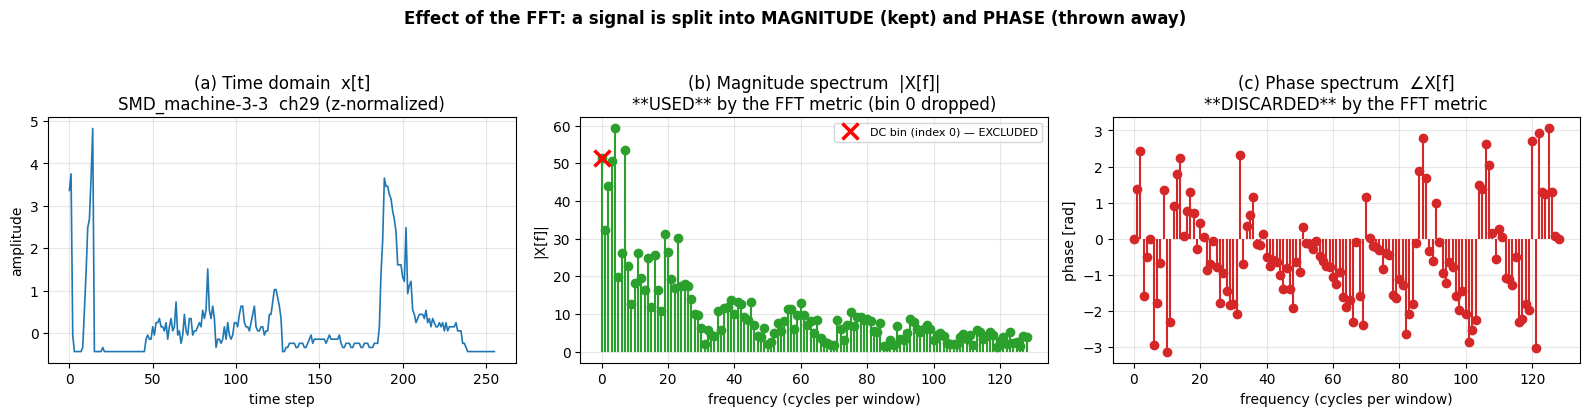

In [4]:
x = norm[medoid_idx][ch]
mag, pha = mag_spectrum(x), phase_spectrum(x)
k = np.arange(mag.shape[0])                     # frequency bin = cycles per window
name = short(names[medoid_idx])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(np.arange(L), x, color="#1f77b4", lw=1.2)
ax[0].set_title(f"(a) Time domain  x[t]\n{name}  ch{ch} (z-normalized)")
ax[0].set_xlabel("time step"); ax[0].set_ylabel("amplitude"); ax[0].grid(alpha=0.3)

ax[1].stem(k, mag, basefmt=" ", linefmt="#2ca02c", markerfmt="o")
ax[1].plot(0, mag[0], "rx", ms=11, mew=2.5, label="DC bin (index 0) — EXCLUDED")
ax[1].set_title("(b) Magnitude spectrum  |X[f]|\n**USED** by the FFT metric (bin 0 dropped)")
ax[1].set_xlabel("frequency (cycles per window)"); ax[1].set_ylabel("|X[f]|")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

ax[2].stem(k, pha, basefmt=" ", linefmt="#d62728", markerfmt="o")
ax[2].set_title("(c) Phase spectrum  \u2220X[f]\n**DISCARDED** by the FFT metric")
ax[2].set_xlabel("frequency (cycles per window)"); ax[2].set_ylabel("phase [rad]")
ax[2].grid(alpha=0.3)

fig.suptitle("Effect of the FFT: a signal is split into MAGNITUDE (kept) and PHASE (thrown away)", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 2. Why 'fft' is phase-robust

Circularly shifting a signal in time changes only its **phase**, not its **magnitude spectrum** (DFT shift theorem).
So the raw-waveform (Pearson) correlation collapses, while the magnitude-spectrum correlation stays ≈ 1 — which is
exactly the invariance the metric wants when matching normal shapes that are not time-aligned across machines.

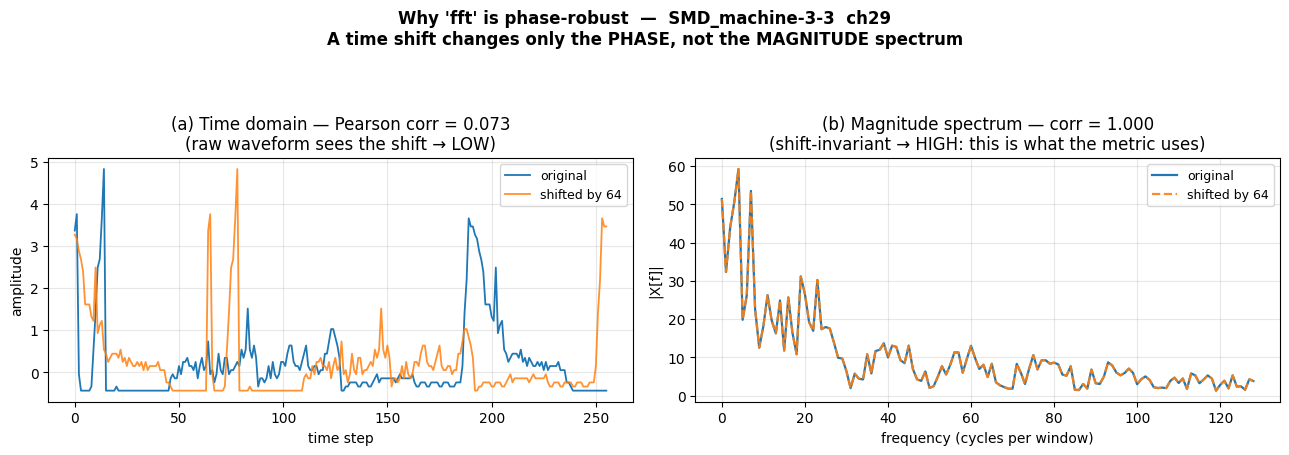

In [5]:
xs = np.roll(x, shift)                       # circular time shift
mx, mxs = mag_spectrum(x), mag_spectrum(xs)
k = np.arange(mx.shape[0])
pear = _corr(x, xs)                           # raw-waveform correlation
fftc = _corr(mx[1:], mxs[1:])                 # magnitude-spectrum corr (bin 0 dropped)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].plot(x, label="original", color="#1f77b4", lw=1.3)
ax[0].plot(xs, label=f"shifted by {shift}", color="#ff7f0e", lw=1.3, alpha=0.85)
ax[0].set_title(f"(a) Time domain — Pearson corr = {pear:.3f}\n(raw waveform sees the shift \u2192 LOW)")
ax[0].set_xlabel("time step"); ax[0].set_ylabel("amplitude"); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

ax[1].plot(k, mx, label="original", color="#1f77b4", lw=1.6)
ax[1].plot(k, mxs, label=f"shifted by {shift}", color="#ff7f0e", lw=1.6, ls="--", alpha=0.9)
ax[1].set_title(f"(b) Magnitude spectrum — corr = {fftc:.3f}\n(shift-invariant \u2192 HIGH: this is what the metric uses)")
ax[1].set_xlabel("frequency (cycles per window)"); ax[1].set_ylabel("|X[f]|"); ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)

fig.suptitle(f"Why 'fft' is phase-robust  —  {name}  ch{ch}\n"
             "A time shift changes only the PHASE, not the MAGNITUDE spectrum", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## 3. Similarity matrices — Pearson (raw) vs FFT (magnitude)

Series-vs-series similarity over the train pool under each metric. Pearson on the raw waveforms is noisy and near-zero
(shapes are not time-aligned); the FFT magnitude-spectrum similarity reveals consistent shared structure. The medoid
(defined under the FFT metric) is boxed in green.

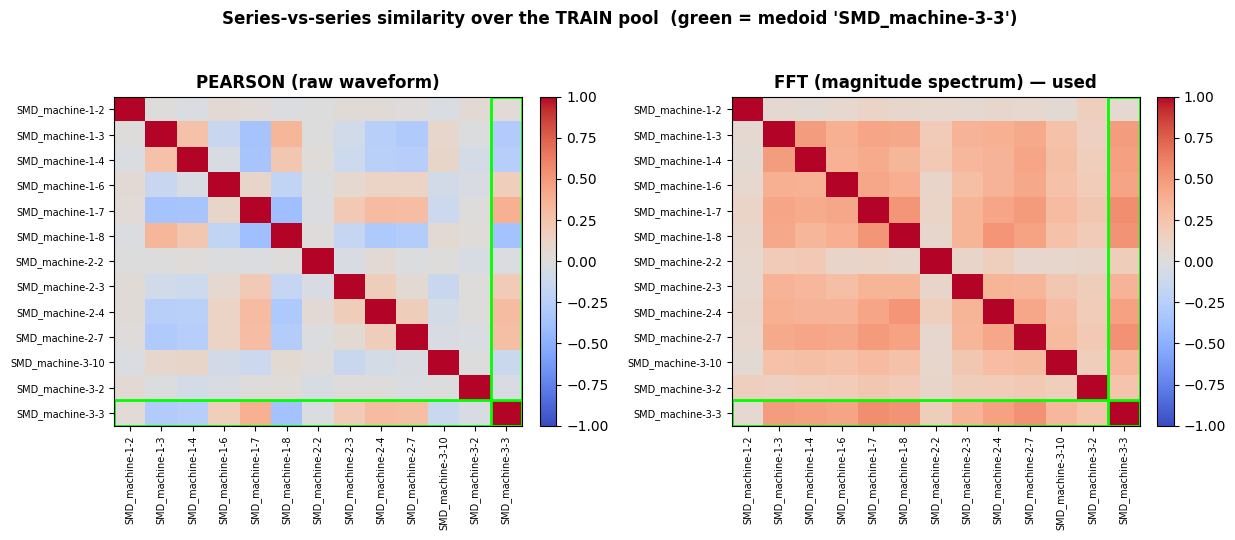

In [6]:
labels = [short(n) for n in names]
fig, ax = plt.subplots(1, 2, figsize=(max(11, 0.5 * len(names) + 6), max(5, 0.42 * len(names))))
for a, (S, title) in zip(ax, [(sim_pearson, "PEARSON (raw waveform)"),
                               (sim_fft, "FFT (magnitude spectrum) — used")]):
    im = a.imshow(S, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    a.set_xticks(range(len(labels))); a.set_yticks(range(len(labels)))
    a.set_xticklabels(labels, rotation=90, fontsize=7); a.set_yticklabels(labels, fontsize=7)
    a.set_title(title, fontweight="bold")
    a.add_patch(plt.Rectangle((-0.5, medoid_idx - 0.5), len(labels), 1, fill=False, edgecolor="lime", lw=2))
    a.add_patch(plt.Rectangle((medoid_idx - 0.5, -0.5), 1, len(labels), fill=False, edgecolor="lime", lw=2))
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
fig.suptitle(f"Series-vs-series similarity over the TRAIN pool  (green = medoid '{short(names[medoid_idx])}')", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4. Medoid selection

Mean off-diagonal similarity of each series to all the others, under each metric. The medoid is the argmax under the
**FFT** metric — note how differently the two metrics rank the series.

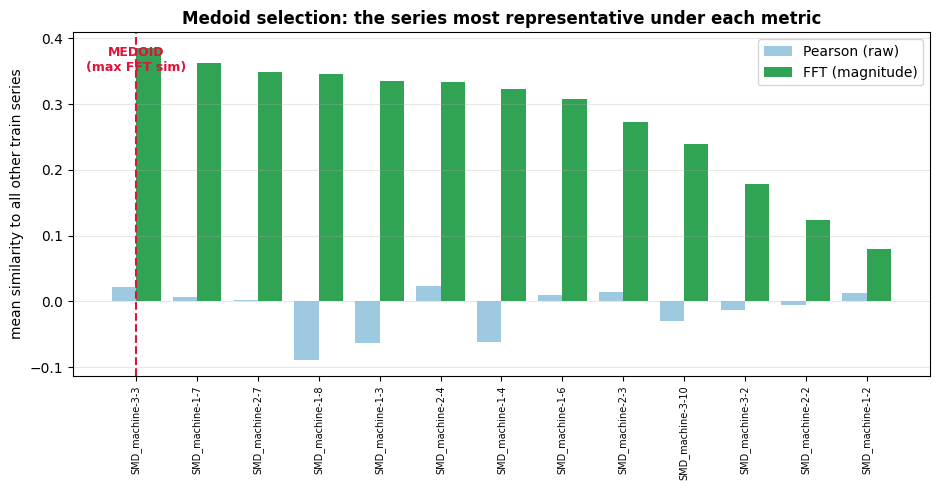

In [7]:
def mean_off(S):
    M = S.copy(); np.fill_diagonal(M, np.nan)
    return np.nanmean(M, axis=1)

mp, mf = mean_off(sim_pearson), mean_off(sim_fft)
order = np.argsort(mf)[::-1]                  # sort by the metric that decides
xpos = np.arange(len(names)); w = 0.4

fig, ax = plt.subplots(figsize=(max(9, 0.5 * len(names) + 3), 5))
ax.bar(xpos - w / 2, mp[order], w, label="Pearson (raw)", color="#9ecae1")
ax.bar(xpos + w / 2, mf[order], w, label="FFT (magnitude)", color="#31a354")
star = list(order).index(medoid_idx)
ax.axvline(star, color="crimson", ls="--", lw=1.5)
ax.annotate("MEDOID\n(max FFT sim)", (star, ax.get_ylim()[1]), textcoords="offset points",
            xytext=(0, -28), ha="center", color="crimson", fontsize=9, fontweight="bold")
ax.set_xticks(xpos); ax.set_xticklabels([labels[i] for i in order], rotation=90, fontsize=7)
ax.set_ylabel("mean similarity to all other train series")
ax.set_title("Medoid selection: the series most representative under each metric", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## 5. Real train pair: FFT sees structure Pearson misses

The real train pair whose FFT similarity most exceeds its Pearson similarity. Panels plot a single channel for
readability, while the annotated similarity numbers are the **channel-averaged** matrix values (as the metric computes them).

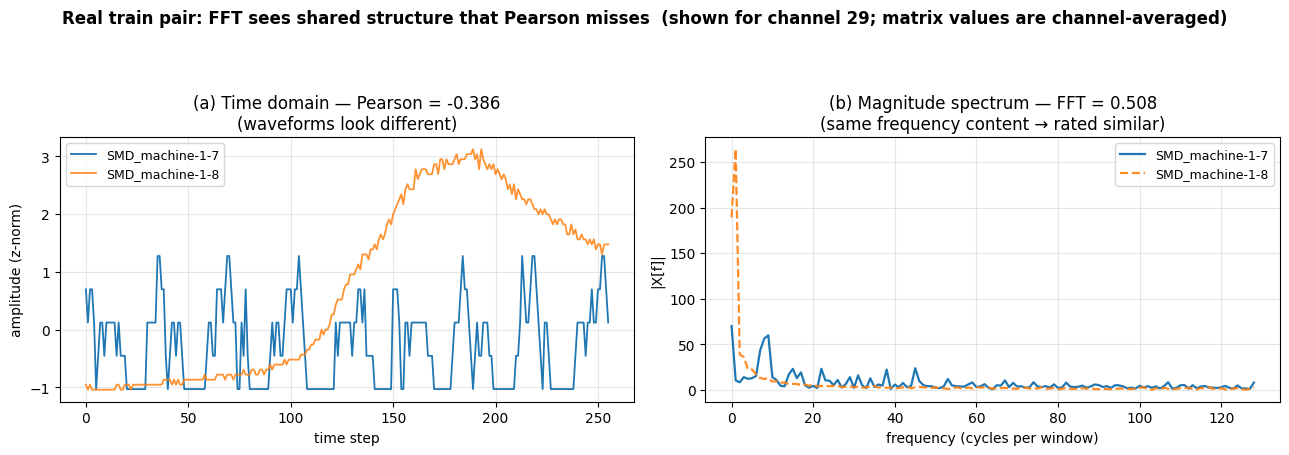

contrast pair (max FFT−Pearson gap): SMD_machine-1-7 vs SMD_machine-1-8


In [8]:
gap = sim_fft - sim_pearson
np.fill_diagonal(gap, -np.inf)
i, j = np.unravel_index(np.argmax(gap), gap.shape)
xi, xj = norm[i, ch], norm[j, ch]
mi, mj = mag_spectrum(xi), mag_spectrum(xj)
k = np.arange(mi.shape[0])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].plot(xi, label=short(names[i]), color="#1f77b4", lw=1.3)
ax[0].plot(xj, label=short(names[j]), color="#ff7f0e", lw=1.3, alpha=0.85)
ax[0].set_title(f"(a) Time domain — Pearson = {sim_pearson[i, j]:.3f}\n(waveforms look different)")
ax[0].set_xlabel("time step"); ax[0].set_ylabel("amplitude (z-norm)"); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

ax[1].plot(k, mi, label=short(names[i]), color="#1f77b4", lw=1.6)
ax[1].plot(k, mj, label=short(names[j]), color="#ff7f0e", lw=1.6, ls="--", alpha=0.9)
ax[1].set_title(f"(b) Magnitude spectrum — FFT = {sim_fft[i, j]:.3f}\n(same frequency content \u2192 rated similar)")
ax[1].set_xlabel("frequency (cycles per window)"); ax[1].set_ylabel("|X[f]|"); ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)

fig.suptitle(f"Real train pair: FFT sees shared structure that Pearson misses  "
             f"(shown for channel {ch}; matrix values are channel-averaged)", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
print(f"contrast pair (max FFT\u2212Pearson gap): {short(names[i])} vs {short(names[j])}")

## 6. Correlation of the chosen normal signal with all the others (violin)

How correlated is the **medoid** (the chosen global normal signal) with every other training series? Each violin shows
the spread of the **per-channel** correlations (medoid-vs-other, all `F` channels × the other series — the values that
get averaged in step 5 of the earlier explanation). The dots are the **per-series channel-averaged** similarities (the
exact numbers that drive medoid selection), and the red line is their mean (the medoid's `mean_similarity`). The FFT
(magnitude) distribution sits clearly higher and tighter than Pearson (raw), which is why the medoid is chosen under FFT.

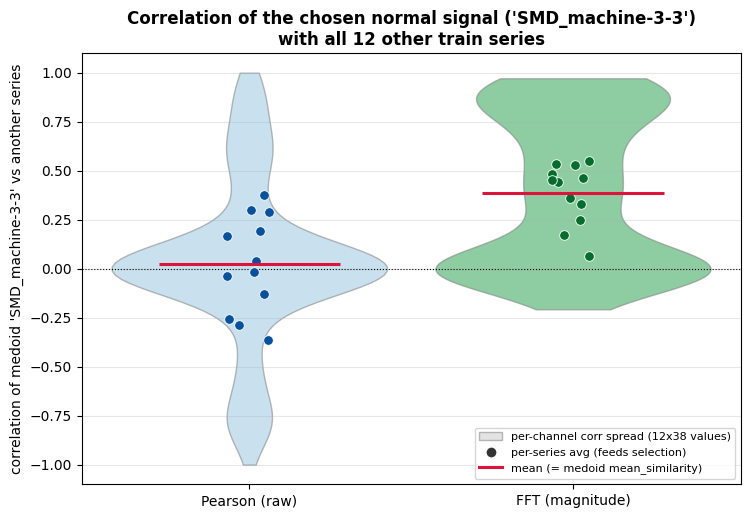

medoid 'SMD_machine-3-3':  FFT mean sim to others = 0.385  |  Pearson mean = 0.022


In [9]:
# Correlation of the chosen normal signal (medoid) vs every other train series
m = medoid_idx
others = [j for j in range(N) if j != m]

# feature representations exactly as similarity_matrix builds them
feats_fft  = np.abs(np.fft.rfft(norm, axis=2))[:, :, 1:]   # (N, F, 128) magnitude spectra
feats_pear = norm                                          # (N, F, 256) raw waveforms

# per-CHANNEL correlations medoid-vs-other (the values that get averaged): F per other series
ch_fft  = np.array([_corr(feats_fft[m, f],  feats_fft[j, f])  for j in others for f in range(F)])
ch_pear = np.array([_corr(feats_pear[m, f], feats_pear[j, f]) for j in others for f in range(F)])

# per-SERIES channel-averaged similarity (what medoid selection actually uses): 1 per other series
ser_fft  = np.array([sim_fft[m, j]     for j in others])
ser_pear = np.array([sim_pearson[m, j] for j in others])

fig, ax = plt.subplots(figsize=(8.5, 5.6))
parts = ax.violinplot([ch_pear, ch_fft], positions=[1, 2], widths=0.85,
                      showmeans=False, showextrema=False)
for pc, c in zip(parts["bodies"], ["#9ecae1", "#31a354"]):
    pc.set_facecolor(c); pc.set_alpha(0.55); pc.set_edgecolor("gray")

jit = np.random.default_rng(0)
for pos, ser, c in [(1, ser_pear, "#08519c"), (2, ser_fft, "#006d2c")]:
    xj = pos + (jit.random(len(ser)) - 0.5) * 0.14
    ax.scatter(xj, ser, s=48, color=c, edgecolor="white", linewidth=0.6, zorder=3)
    ax.hlines(ser.mean(), pos - 0.28, pos + 0.28, color="crimson", lw=2.2, zorder=4)

ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xticks([1, 2]); ax.set_xticklabels(["Pearson (raw)", "FFT (magnitude)"])
ax.set_ylabel(f"correlation of medoid '{short(names[m])}' vs another series")
ax.set_title(f"Correlation of the chosen normal signal ('{short(names[m])}')\n"
             f"with all {len(others)} other train series", fontweight="bold")
ax.grid(alpha=0.3, axis="y")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[
    Patch(facecolor="#cccccc", alpha=0.55, edgecolor="gray",
          label=f"per-channel corr spread ({len(others)}x{F} values)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#333333",
           markeredgecolor="white", markersize=8, label="per-series avg (feeds selection)"),
    Line2D([0], [0], color="crimson", lw=2.2, label="mean (= medoid mean_similarity)"),
], fontsize=8, loc="lower right")
plt.show()

print(f"medoid '{short(names[m])}':  FFT mean sim to others = {ser_fft.mean():.3f}  |  "
      f"Pearson mean = {ser_pear.mean():.3f}")